In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download(
    "andrewmvd/heart-failure-clinical-data"
)

print("Path to dataset files:", path)

100%|██████████| 3.97k/3.97k [00:00<00:00, 5.33MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/andrewmvd/heart-failure-clinical-data/versions/1


Load Dataset

In [2]:
import os
import pandas as pd

# Find the downloaded dataset file
files = os.listdir(path)
print("Files in dataset folder:", files)

# Load CSV file
csv_file = [file for file in files if file.endswith(".csv")][0]

file_path = os.path.join(path, csv_file)

df = pd.read_csv(file_path)

# Display first 5 rows
print("\nFirst 5 rows of the dataset:")
display(df.head())

Files in dataset folder: ['heart_failure_clinical_records_dataset.csv']

First 5 rows of the dataset:


,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


Summarize Datase

In [4]:
# STEP 3: Summarize Dataset

print("=" * 50)
print("DATASET SUMMARY")
print("=" * 50)

# Number of rows and columns
print("\n1. Dataset Shape:")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

# Data types
print("\n2. Data Types:")
print(df.dtypes)

# Missing values
print("\n3. Missing Values:")
print(df.isnull().sum())

# Complete information
print("\n4. Dataset Information:")
df.info()

DATASET SUMMARY

1. Dataset Shape:
Rows: 299
Columns: 13

2. Data Types:
age                         float64
anaemia                       int64
creatinine_phosphokinase      int64
diabetes                      int64
ejection_fraction             int64
high_blood_pressure           int64
platelets                   float64
serum_creatinine            float64
serum_sodium                  int64
sex                           int64
smoking                       int64
time                          int64
DEATH_EVENT                   int64
dtype: object

3. Missing Values:
age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
sex                         0
smoking                     0
time                        0
DEATH_EVENT                 0
dtype: int64

4. Dataset Informatio

Visualize Missing Values

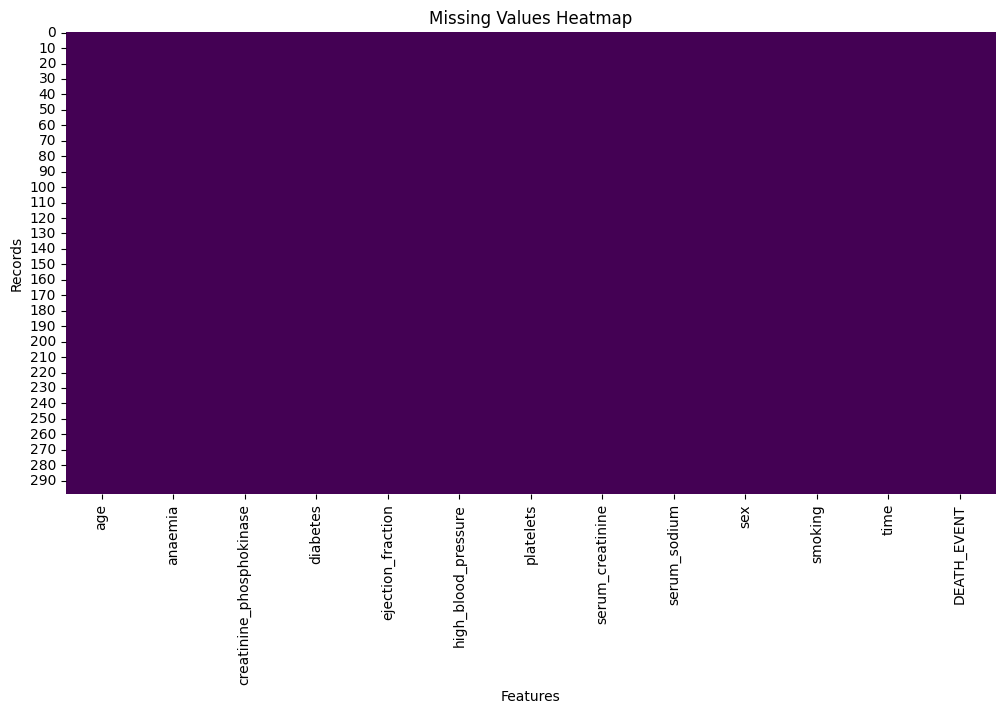

In [6]:
# STEP 4: Visualize Missing Values

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))

sns.heatmap(
    df.isnull(),
    cbar=False,
    cmap="viridis"
)

plt.title("Missing Values Heatmap")
plt.xlabel("Features")
plt.ylabel("Records")

plt.show()

Plot Distributions

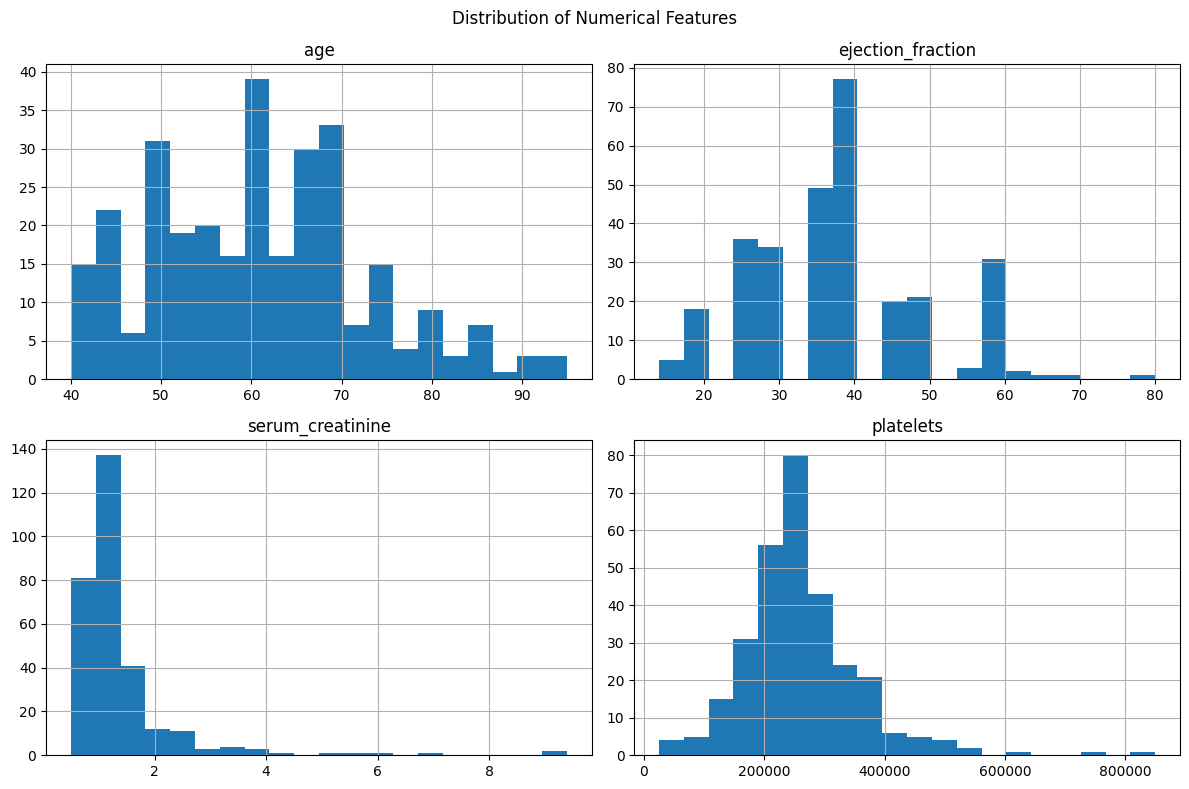

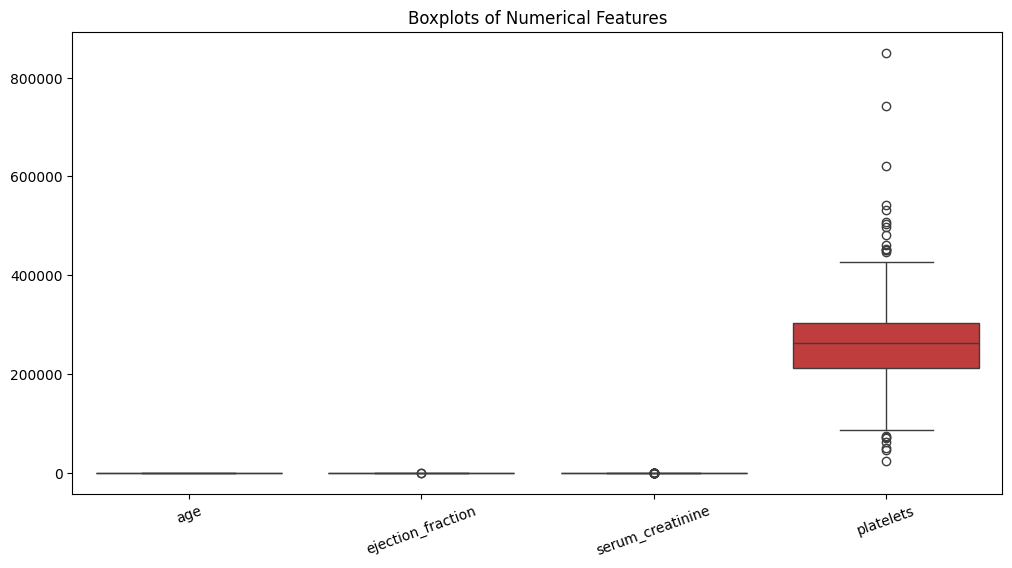

In [7]:
# STEP 5: Plot Distributions

import matplotlib.pyplot as plt
import seaborn as sns

# Numerical features to visualize
features = [
    "age",
    "ejection_fraction",
    "serum_creatinine",
    "platelets"
]

# Histograms
df[features].hist(
    figsize=(12, 8),
    bins=20
)

plt.suptitle("Distribution of Numerical Features")
plt.tight_layout()
plt.show()


# Boxplots
plt.figure(figsize=(12, 6))

sns.boxplot(data=df[features])

plt.title("Boxplots of Numerical Features")
plt.xticks(rotation=20)
plt.show()

Impute Missing Values

In [8]:
# STEP 6: Impute Missing Values

import numpy as np

# Create a copy so the original dataset remains unchanged
clean_df = df.copy()

# ---------------------------------------------------
# 1. Create a few missing values for demonstration
# ---------------------------------------------------

np.random.seed(42)

# Numerical features
clean_df.loc[
    np.random.choice(clean_df.index, 5, replace=False),
    "serum_creatinine"
] = np.nan

clean_df.loc[
    np.random.choice(clean_df.index, 5, replace=False),
    "age"
] = np.nan

# Categorical feature
clean_df.loc[
    np.random.choice(clean_df.index, 5, replace=False),
    "smoking"
] = np.nan

print("Missing values BEFORE imputation:")
print(clean_df.isnull().sum())


# ---------------------------------------------------
# 2. Numerical Imputation using Median
# ---------------------------------------------------

numerical_columns = [
    "age",
    "creatinine_phosphokinase",
    "ejection_fraction",
    "platelets",
    "serum_creatinine",
    "serum_sodium",
    "time"
]

for column in numerical_columns:
    clean_df[column] = clean_df[column].fillna(
        clean_df[column].median()
    )


# ---------------------------------------------------
# 3. Categorical Imputation using Mode
# ---------------------------------------------------

categorical_columns = [
    "anaemia",
    "diabetes",
    "high_blood_pressure",
    "sex",
    "smoking"
]

for column in categorical_columns:
    clean_df[column] = clean_df[column].fillna(
        clean_df[column].mode()[0]
    )


# ---------------------------------------------------
# 4. Check missing values AFTER imputation
# ---------------------------------------------------

print("\nMissing values AFTER imputation:")
print(clean_df.isnull().sum())

print("\nTotal missing values:",
      clean_df.isnull().sum().sum())

Missing values BEFORE imputation:
age                         5
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            5
serum_sodium                0
sex                         0
smoking                     5
time                        0
DEATH_EVENT                 0
dtype: int64

Missing values AFTER imputation:
age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
sex                         0
smoking                     0
time                        0
DEATH_EVENT                 0
dtype: int64

Total missing values: 0


Remove Outliers

In [9]:
# STEP 7: Remove Outliers using IQR method

# Numerical columns where we will check for outliers
outlier_columns = [
    "age",
    "creatinine_phosphokinase",
    "ejection_fraction",
    "platelets",
    "serum_creatinine",
    "serum_sodium"
]

print("Shape BEFORE removing outliers:", clean_df.shape)

# Store original number of rows
before_rows = len(clean_df)

# Remove outliers using IQR
for column in outlier_columns:

    Q1 = clean_df[column].quantile(0.25)
    Q3 = clean_df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    clean_df = clean_df[
        (clean_df[column] >= lower_bound) &
        (clean_df[column] <= upper_bound)
    ]

# Number of rows removed
after_rows = len(clean_df)

print("Shape AFTER removing outliers:", clean_df.shape)
print("Rows removed:", before_rows - after_rows)

Shape BEFORE removing outliers: (299, 13)
Shape AFTER removing outliers: (225, 13)
Rows removed: 74


Correct Inconsistencies

In [10]:
# STEP 8: Correct Inconsistencies

print("=" * 50)
print("CHECKING FOR INCONSISTENCIES")
print("=" * 50)

# 1. Check invalid age
invalid_age = (
    (clean_df["age"] <= 0) |
    (clean_df["age"] > 120)
)

print("\nInvalid age entries:", invalid_age.sum())

# Correct invalid age using median
if invalid_age.sum() > 0:
    clean_df.loc[invalid_age, "age"] = clean_df["age"].median()


# 2. Check invalid ejection fraction
invalid_ef = (
    (clean_df["ejection_fraction"] <= 0) |
    (clean_df["ejection_fraction"] > 100)
)

print("Invalid ejection fraction entries:",
      invalid_ef.sum())


# 3. Check invalid serum creatinine
invalid_creatinine = (
    clean_df["serum_creatinine"] <= 0
)

print("Invalid serum creatinine entries:",
      invalid_creatinine.sum())


# 4. Check invalid serum sodium
invalid_sodium = (
    clean_df["serum_sodium"] <= 0
)

print("Invalid serum sodium entries:",
      invalid_sodium.sum())


# 5. Check binary columns
binary_columns = [
    "anaemia",
    "diabetes",
    "high_blood_pressure",
    "sex",
    "smoking",
    "DEATH_EVENT"
]

print("\nBinary column check:")

for column in binary_columns:

    invalid_values = clean_df[
        ~clean_df[column].isin([0, 1])
    ]

    print(
        column,
        "-> invalid entries:",
        len(invalid_values)
    )


print("\nInconsistency checking completed.")

CHECKING FOR INCONSISTENCIES

Invalid age entries: 0
Invalid ejection fraction entries: 0
Invalid serum creatinine entries: 0
Invalid serum sodium entries: 0

Binary column check:
anaemia -> invalid entries: 0
diabetes -> invalid entries: 0
high_blood_pressure -> invalid entries: 0
sex -> invalid entries: 0
smoking -> invalid entries: 0
DEATH_EVENT -> invalid entries: 0

Inconsistency checking completed.


Feature Engineering

In [11]:
# STEP 9: Feature Engineering

from sklearn.preprocessing import MinMaxScaler

# ---------------------------------------------------
# 1. Create age_group
# ---------------------------------------------------

clean_df["age_group"] = pd.cut(
    clean_df["age"],
    bins=[0, 40, 60, np.inf],
    labels=["<40", "40-60", ">60"],
    right=False
)

print("Age Group Distribution:")
print(clean_df["age_group"].value_counts())


# ---------------------------------------------------
# 2. Normalize features needed for risk_score
# ---------------------------------------------------

risk_scaler = MinMaxScaler()

clean_df[
    ["ejection_fraction_norm",
     "serum_creatinine_norm"]
] = risk_scaler.fit_transform(
    clean_df[
        ["ejection_fraction",
         "serum_creatinine"]
    ]
)


# ---------------------------------------------------
# 3. Create risk_score
# ---------------------------------------------------

clean_df["risk_score"] = (
    clean_df["ejection_fraction_norm"] *
    clean_df["serum_creatinine_norm"]
)


# ---------------------------------------------------
# 4. Display result
# ---------------------------------------------------

print("\nNew Features Created:")

display(
    clean_df[
        [
            "age",
            "age_group",
            "ejection_fraction",
            "serum_creatinine",
            "risk_score"
        ]
    ].head(10)
)

Age Group Distribution:
age_group
>60      128
40-60     97
<40        0
Name: count, dtype: int64

New Features Created:


,age,age_group,ejection_fraction,serum_creatinine,risk_score
0,75.0,>60,20,1.9,0.101961
2,65.0,>60,20,1.3,0.054902
3,50.0,40-60,20,1.9,0.101961
5,90.0,>60,40,2.1,0.509804
6,75.0,>60,15,1.2,0.007843
8,65.0,>60,65,1.5,0.600000
9,80.0,>60,35,1.1,0.137255
11,62.0,>60,25,0.9,0.043137
12,45.0,40-60,30,1.1,0.104575
13,50.0,40-60,38,1.1,0.156863


Encode Categorical Variables

In [12]:
# STEP 10: Encode Categorical Variables

# One-hot encode age_group
clean_df = pd.get_dummies(
    clean_df,
    columns=["age_group"],
    prefix="age_group",
    dtype=int
)

# Display the new encoded columns
print("Encoded age_group columns:")

encoded_columns = [
    column for column in clean_df.columns
    if column.startswith("age_group_")
]

print(encoded_columns)

print("\nSample of encoded data:")
display(
    clean_df[
        ["age_group_<40", "age_group_40-60", "age_group_>60"]
    ].head(10)
)

Encoded age_group columns:
['age_group_<40', 'age_group_40-60', 'age_group_>60']

Sample of encoded data:


,age_group_<40,age_group_40-60,age_group_>60
0,0,0,1
2,0,0,1
3,0,1,0
5,0,0,1
6,0,0,1
8,0,0,1
9,0,0,1
11,0,0,1
12,0,1,0
13,0,1,0


Normalize Features using MinMaxScaler.

In [13]:
# STEP 11: Normalize Numerical Features

from sklearn.preprocessing import MinMaxScaler

# Numerical features to normalize
scale_columns = [
    "age",
    "creatinine_phosphokinase",
    "ejection_fraction",
    "platelets",
    "serum_creatinine",
    "serum_sodium",
    "time"
]

# Create scaler
scaler = MinMaxScaler()

# Apply Min-Max normalization
clean_df[scale_columns] = scaler.fit_transform(
    clean_df[scale_columns]
)

# Display normalized features
print("Normalized numerical features:")
display(clean_df[scale_columns].head())

# Verify range
print("\nMinimum values:")
print(clean_df[scale_columns].min())

print("\nMaximum values:")
print(clean_df[scale_columns].max())

Normalized numerical features:


,age,creatinine_phosphokinase,ejection_fraction,platelets,serum_creatinine,serum_sodium,time
0,0.636364,0.470990,0.117647,0.468852,0.866667,0.217391,0.000000
2,0.454545,0.098976,0.117647,0.131148,0.466667,0.173913,0.010676
3,0.181818,0.069113,0.117647,0.288525,0.866667,0.521739,0.010676
5,0.909091,0.014505,0.509804,0.268852,1.000000,0.304348,0.014235
6,0.636364,0.184300,0.019608,0.016393,0.400000,0.521739,0.021352



Minimum values:
age                         0.0
creatinine_phosphokinase    0.0
ejection_fraction           0.0
platelets                   0.0
serum_creatinine            0.0
serum_sodium                0.0
time                        0.0
dtype: float64

Maximum values:
age                         1.0
creatinine_phosphokinase    1.0
ejection_fraction           1.0
platelets                   1.0
serum_creatinine            1.0
serum_sodium                1.0
time                        1.0
dtype: float64


Compute Summary Statistics

In [14]:
# STEP 12: Summary Statistics Before and After Cleaning

# Numerical columns
statistics_columns = [
    "age",
    "creatinine_phosphokinase",
    "ejection_fraction",
    "platelets",
    "serum_creatinine",
    "serum_sodium",
    "time"
]

# Statistics BEFORE cleaning
before_stats = df[statistics_columns].agg(
    ["mean", "median", "std"]
)

# Statistics AFTER cleaning
after_stats = clean_df[statistics_columns].agg(
    ["mean", "median", "std"]
)

print("=" * 60)
print("STATISTICS BEFORE CLEANING")
print("=" * 60)

display(before_stats)

print("=" * 60)
print("STATISTICS AFTER CLEANING")
print("=" * 60)

display(after_stats)

STATISTICS BEFORE CLEANING


,age,creatinine_phosphokinase,ejection_fraction,platelets,serum_creatinine,serum_sodium,time
mean,60.833893,581.839465,38.083612,263358.029264,1.39388,136.625418,130.260870
median,60.000000,250.000000,38.000000,262000.000000,1.10000,137.000000,115.000000
std,11.894809,970.287881,11.834841,97804.236869,1.03451,4.412477,77.614208


STATISTICS AFTER CLEANING


,age,creatinine_phosphokinase,ejection_fraction,platelets,serum_creatinine,serum_sodium,time
mean,0.380795,0.261085,0.473813,0.440828,0.352593,0.522899,0.455896
median,0.363636,0.155290,0.470588,0.462295,0.333333,0.521739,0.412811
std,0.217129,0.238277,0.229148,0.221575,0.217791,0.165556,0.273469


Validate Cleaning

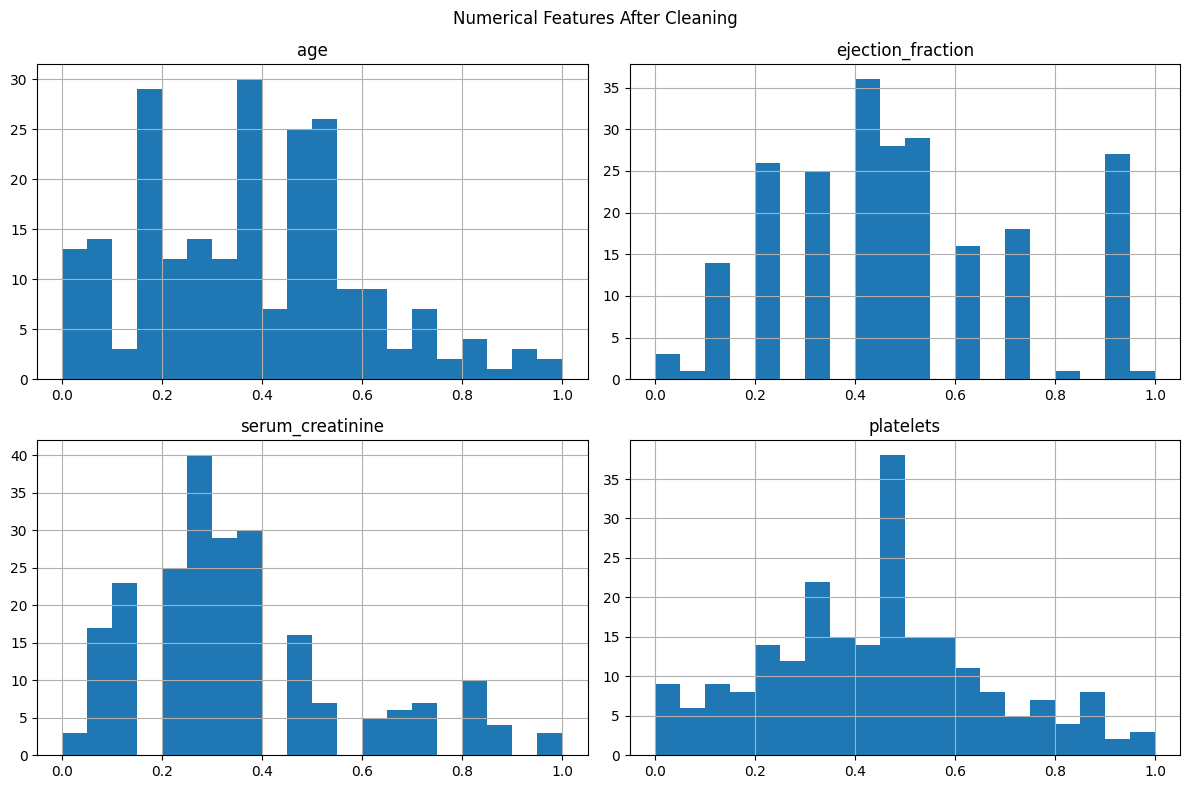

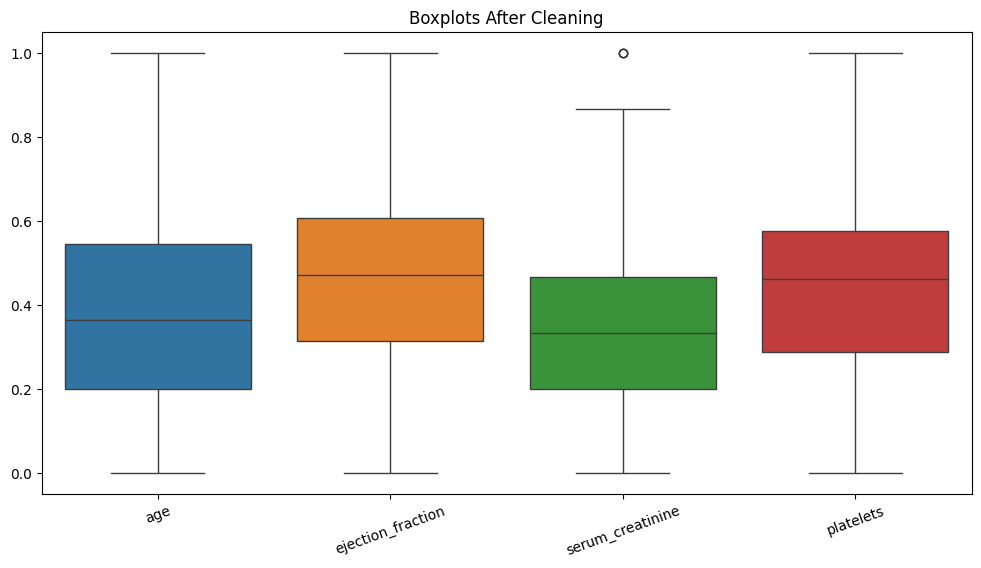

In [15]:
# STEP 13: Validate Cleaning

import matplotlib.pyplot as plt
import seaborn as sns

# Numerical features to validate
validation_features = [
    "age",
    "ejection_fraction",
    "serum_creatinine",
    "platelets"
]

# ---------------------------------------------------
# Histograms AFTER cleaning
# ---------------------------------------------------

clean_df[validation_features].hist(
    figsize=(12, 8),
    bins=20
)

plt.suptitle("Numerical Features After Cleaning")
plt.tight_layout()
plt.show()


# ---------------------------------------------------
# Boxplots AFTER cleaning
# ---------------------------------------------------

plt.figure(figsize=(12, 6))

sns.boxplot(
    data=clean_df[validation_features]
)

plt.title("Boxplots After Cleaning")
plt.xticks(rotation=20)

plt.show()

Final Missing Value Check

In [16]:
# STEP 14: Final Missing Value Check

print("=" * 60)
print("FINAL DATASET VALIDATION")
print("=" * 60)

# Check missing values in every column
missing_values = clean_df.isnull().sum()

print("\nMissing values in each column:")
print(missing_values)

# Calculate total missing values
total_missing = clean_df.isnull().sum().sum()

print("\nTotal missing values:", total_missing)

# Final conclusion
if total_missing == 0:
    print("\n✓ Cleaning successful: No missing values remain.")
else:
    print("\n⚠ Missing values still remain. Further cleaning is required.")

# Final dataset information
print("\nFinal dataset shape:", clean_df.shape)

print("\nFinal dataset preview:")
display(clean_df.head())

FINAL DATASET VALIDATION

Missing values in each column:
age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
sex                         0
smoking                     0
time                        0
DEATH_EVENT                 0
ejection_fraction_norm      0
serum_creatinine_norm       0
risk_score                  0
age_group_<40               0
age_group_40-60             0
age_group_>60               0
dtype: int64

Total missing values: 0

✓ Cleaning successful: No missing values remain.

Final dataset shape: (225, 19)

Final dataset preview:


,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT,ejection_fraction_norm,serum_creatinine_norm,risk_score,age_group_<40,age_group_40-60,age_group_>60
0,0.636364,0,0.470990,0,0.117647,1,0.468852,0.866667,0.217391,1,0.0,0.000000,1,0.117647,0.866667,0.101961,0,0,1
2,0.454545,0,0.098976,0,0.117647,0,0.131148,0.466667,0.173913,1,1.0,0.010676,1,0.117647,0.466667,0.054902,0,0,1
3,0.181818,1,0.069113,0,0.117647,0,0.288525,0.866667,0.521739,1,0.0,0.010676,1,0.117647,0.866667,0.101961,0,1,0
5,0.909091,1,0.014505,0,0.509804,1,0.268852,1.000000,0.304348,1,1.0,0.014235,1,0.509804,1.000000,0.509804,0,0,1
6,0.636364,1,0.184300,0,0.019608,0,0.016393,0.400000,0.521739,1,0.0,0.021352,1,0.019608,0.400000,0.007843,0,0,1
